In [ ]:
import glob
from scipy.io import loadmat

import os
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, PathSolver

from sklearn.metrics import mean_squared_error, mean_absolute_error,root_mean_squared_error

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import math
import random

import sys

sys.path.append(os.path.abspath('./src'))
from scene_generation.core import Scene
from scene_generation.utils import rect_from_point_and_size, get_utm_epsg_code_from_gps, gps_to_utm_xy, get_center_subarray
from scene_generation.empirical_pathloss_model import pathloss_38901
from scene_generation.unet.unet_model_rt import UNet

# Mitsuba components for advanced scene operation
import mitsuba as mi
import drjit as dr

In [168]:
# LOS or NLOS for measurement type
measurement_type1 = "NLOS"
measurement_type2 = "LOS"
def initialize_header(measurement_type):
    # Initialize header data structure
    header_dict = {"file_name":[], "mea_idx":[]}
    header_folder_path = "./data/measurements/Boulder_Downtown/Measurements/BoulderDowntown_28GHz_{}/Header files/".format(measurement_type)  
    header_mat_files = glob.glob(f"{header_folder_path}/*.mat")  
    print(header_mat_files[:3]) 
    return header_dict, header_folder_path, header_mat_files
NLOS_header_dict, NLOS_header_folder_path, NLOS_header_mat_files = initialize_header(measurement_type1)
LOS_header_dict, LOS_header_folder_path, LOS_header_mat_files = initialize_header(measurement_type2)
def extract_header_info(header_dict, header_mat_files):
    # MATLAB to Python data conversion
    for mat_file_path in header_mat_files: 

        #Load the .mat file
        data = loadmat(mat_file_path)

        # Store basic file info
        header_dict["file_name"].append(os.path.basename(mat_file_path))
        header_dict["mea_idx"].append(os.path.basename(mat_file_path)[4:4+4])

        # Recursive struct parsing
        for key in data:
            if not key.startswith("__"):  # Ignore metadata keys
                value = data[key]
                if isinstance(value, np.ndarray) and value.dtype.names:
                        for name in value.dtype.names:
                            tmp_value =  data[key][0][name]
                            try:
                                tmp_value = tmp_value.item()
                                tmp_value = tmp_value.squeeze()
                                tmp_value = tmp_value.item()
                            except Exception as e:
                                pass
                            if ("{}_{}".format(key, name)) not in header_dict:
                                header_dict[("{}_{}".format(key, name))] = []
                            header_dict[("{}_{}".format(key, name))].append(tmp_value)
                else:
                    tmp_value = data[key]
                    try:
                        tmp_value = tmp_value.item()
                        tmp_value = tmp_value.squeeze()
                        tmp_value = tmp_value.item()
                    except Exception as e:
                        pass
                    if "{}".format(key) not in header_dict:
                        header_dict[("{}".format(key))] = []
                    header_dict[("{}".format(key))].append(tmp_value)

                    
    return header_dict
NLOS_header_dict = extract_header_info(NLOS_header_dict, NLOS_header_mat_files)
LOS_header_dict = extract_header_info(LOS_header_dict, LOS_header_mat_files)
NLOS_header_df = pd.DataFrame(NLOS_header_dict)
LOS_header_df = pd.DataFrame(LOS_header_dict)
def assert_errors(header_df):
    # Assert checks for data consistency
    assert header_df['TxData_lat_Deg'].nunique() == 1,"Error: Mupltiple TX latitudes detected"
    assert header_df['TxData_long_Deg'].nunique() == 1,"Error: Mupltiple TX longitudes detected" 
    assert header_df['TxData_alt'].nunique() == 1,"Error: Mupltiple TX altitudes detected" 
assert_errors(NLOS_header_df)
assert_errors(LOS_header_df)
def initialize_MPC(measurement_type):
    # Initialize MPC data structure
    mpc_dict = {"file_name":[], "mea_idx":[]}
    mpc_folder_path = "./data/measurements/Boulder_Downtown/Measurements/BoulderDowntown_28GHz_{}/MPC files/".format(measurement_type)  
    mpc_mat_files = glob.glob(f"{mpc_folder_path}/*.mat")  
    print(mpc_mat_files[:3]) 
    return mpc_dict, mpc_folder_path, mpc_mat_files
NLOS_mpc_dict, NLOS_mpc_folder_path, NLOS_mpc_mat_files = initialize_MPC(measurement_type1)
LOS_mpc_dict, LOS_mpc_folder_path, LOS_mpc_mat_files = initialize_MPC(measurement_type2)
def format_MPC_dict(MPC_dict, MPC_mat_files):
    # MATLAB to Python data conversion
    for mat_file_path in MPC_mat_files: 

        #Load the .mat file
        data = loadmat(mat_file_path)

        # Store basic file info
        MPC_dict["file_name"].append(os.path.basename(mat_file_path))
        MPC_dict["mea_idx"].append(os.path.basename(mat_file_path)[3:3+4])

        # Recursive struct parsing
        for key in data:
            if not key.startswith("__"):  # Ignore metadata keys
                value = data[key]
                if isinstance(value, np.ndarray) and value.dtype.names:
                        for name in value.dtype.names:
                            tmp_value =  data[key][0][name]
                            try:
                                tmp_value = tmp_value.item()
                                tmp_value = tmp_value.squeeze()
                                tmp_value = tmp_value.item()
                            except Exception as e:
                                pass
                            if ("{}_{}".format(key, name)) not in MPC_dict:
                                MPC_dict[("{}_{}".format(key, name))] = []
                            MPC_dict[("{}_{}".format(key, name))].append(tmp_value)
                else:
                    tmp_value = data[key]
                    try:
                        tmp_value = tmp_value.item()
                        tmp_value = tmp_value.squeeze()
                        tmp_value = tmp_value.item()
                    except Exception as e:
                        pass
                    if "{}".format(key) not in MPC_dict:
                        MPC_dict[("{}".format(key))] = []
                    MPC_dict[("{}").format(key)].append(tmp_value)

                    
    return MPC_dict
NLOS_MPC_dict =  format_MPC_dict(NLOS_mpc_dict, NLOS_mpc_mat_files)
LOS_MPC_dict =  format_MPC_dict(LOS_mpc_dict, LOS_mpc_mat_files)

NLOS_MPC_df = pd.DataFrame(NLOS_MPC_dict)
print(NLOS_MPC_df.iloc[0].to_string())
print("\n")

LOS_MPC_df = pd.DataFrame(LOS_MPC_dict)
NLOS_merged_df = pd.merge(NLOS_MPC_df, NLOS_header_df, on='mea_idx', how='inner')  
print(NLOS_merged_df.iloc[0].to_string())
LOS_merged_df = pd.merge(LOS_MPC_df, LOS_header_df, on='mea_idx', how='inner')

['./data/measurements/Boulder_Downtown/Measurements/BoulderDowntown_28GHz_NLOS/Header files/F0002150hdr.mat', './data/measurements/Boulder_Downtown/Measurements/BoulderDowntown_28GHz_NLOS/Header files/F0002142hdr.mat', './data/measurements/Boulder_Downtown/Measurements/BoulderDowntown_28GHz_NLOS/Header files/F0002174hdr.mat']
['./data/measurements/Boulder_Downtown/Measurements/BoulderDowntown_28GHz_LOS/Header files/F0001599hdr.mat', './data/measurements/Boulder_Downtown/Measurements/BoulderDowntown_28GHz_LOS/Header files/F0001587hdr.mat', './data/measurements/Boulder_Downtown/Measurements/BoulderDowntown_28GHz_LOS/Header files/F0001595hdr.mat']
['./data/measurements/Boulder_Downtown/Measurements/BoulderDowntown_28GHz_NLOS/MPC files/MPC2266.mat', './data/measurements/Boulder_Downtown/Measurements/BoulderDowntown_28GHz_NLOS/MPC files/MPC2267.mat', './data/measurements/Boulder_Downtown/Measurements/BoulderDowntown_28GHz_NLOS/MPC files/MPC2259.mat']
['./data/measurements/Boulder_Downtown/M

In [ ]:
scene_dir = "./scenes/Boulder_Downtown"

polygon_points_gps = rect_from_point_and_size(
    NLOS_merged_df.iloc[0]["TxData_long_Deg"],
    NLOS_merged_df.iloc[0]["TxData_lat_Deg"],
    "center", 
    512,
    512
)
min_lon, min_lat = polygon_points_gps[0]
max_lon, max_lat = polygon_points_gps[2]
print(
    f"Check the bbox at http://bboxfinder.com/#{min_lat:.{4}f},{min_lon:.{4}f},{max_lat:.{4}f},{max_lon:.{4}f}"
)
scene_instance = Scene()
scene_instance(
    polygon_points_gps,
    scene_dir,
    None,
    osm_server_addr="https://overpass-api.de/api/interpreter",
    lidar_calibration=False,
    generate_building_map=True,
    ground_material_type="mat-itu_concrete",
    rooftop_material_type = "mat-itu_metal",
    wall_material_type = "mat-itu_brick" 
)

scene = load_scene("{}/scene.xml".format(scene_dir), merge_shapes = False)

Check the bbox at http://bboxfinder.com/#40.0148,-105.2823,40.0194,-105.2763


Parsing buildings: 100%|██████████| 152/152 [00:00<00:00, 542.75it/s]


2025-09-30 02:40:01 WARN wrk5 [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).

In [ ]:
def generate_scene(longitude_deg, latitude_deg, folder):
    """
    Given a set of coordinates, generate a 512x512 Sionna scene
    """
    scene_dir = f"./scenes/{folder}"

    polygon_points_gps = rect_from_point_and_size(
        longitude_deg,
        latitude_deg,
        "center", 
        512,
        512
    )

    min_lon, min_lat = polygon_points_gps[0]
    max_lon, max_lat = polygon_points_gps[2]
    print(
        f"Check the bbox at http://bboxfinder.com/#{min_lat:.{4}f},{min_lon:.{4}f},{max_lat:.{4}f},{max_lon:.{4}f}"
    )
    scene_instance = Scene()
    scene_instance(
        polygon_points_gps,
        scene_dir,
        None,
        osm_server_addr="https://overpass-api.de/api/interpreter",
        lidar_calibration=False,
        generate_building_map=True,
        ground_material_type="mat-itu_concrete",
        rooftop_material_type = "mat-itu_metal",
        wall_material_type = "mat-itu_brick" 
    )
    # Merge_shapes = false so that we can adjust material properties later
    scene = load_scene("{}/scene.xml".format(scene_dir), merge_shapes = False)
    return scene

In [170]:
# function(bounding box, num_rx, num_tx antennas, frequency, scattered density, 
# number of RF augmentation repeatition, building centre location max error) 
# —>(location information_rx, RF_augmnentation*(channel state information: CFR,CIR), 
# and the 3D map w/ and w/o the scatters added and the ground truth information, spatial spectra) 

In [172]:
def plot_scene_2d_height(mi_scene, resolution=200, ax=None):
    """
    Create a 2D top-down view of the scene where color indicates building height.
    
    Parameters:
    -----------
    mi_scene : mitsuba scene object
        The Mitsuba scene to visualize
    resolution : int
        Grid resolution for sampling (higher = more detail but slower)
    ax : matplotlib axis, optional
        Axis to plot on. If None, creates new figure
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    height_grid : 2D numpy array of heights
    """

    # Calculate scene bounding box excluding the ground plane
    bbox = mi.ScalarBoundingBox3f()
    for shape in mi_scene.shapes():
        if "ground" not in shape.id():
            bbox.expand(shape.bbox())
    
    bbox_min = bbox.min
    bbox_max = bbox.max
    
    # Create a grid of points in x-y plane
    x = np.linspace(bbox_min.x, bbox_max.x, resolution)
    y = np.linspace(bbox_min.y, bbox_max.y, resolution)
    xx, yy = np.meshgrid(x, y)
    
    # Start rays from above the scene
    z_start = bbox_max.z + 10  # Start 10 units above highest point
    
    # Flatten grid for ray tracing
    origins = np.stack([xx.flatten(), yy.flatten(), 
                       np.full(xx.size, z_start)], axis=1)
    
    # Shoot rays downward
    directions = np.tile([0, 0, -1], (len(origins), 1))
    
    # Create rays
    rays = mi.Ray3f(
        mi.Vector3f(np.array(origins, dtype=np.float32).T),
        mi.Vector3f(np.array(directions, dtype=np.float32).T)
    )
    
    # Intersect with scene
    si = mi_scene.ray_intersect(rays)
    
    # Extract heights (z-coordinates of intersections)
    heights = np.where(si.is_valid(), si.p.z, np.nan)
    height_grid = heights.reshape(xx.shape)
    
    # Create plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    else:
        fig = ax.get_figure()
    
    # Plot with color indicating height
    im = ax.imshow(height_grid, 
                   extent=[bbox_min.x, bbox_max.x, bbox_min.y, bbox_max.y],
                   origin='lower',
                   cmap='viridis',
                   aspect='equal')
    
    cbar = plt.colorbar(im, ax=ax, label='Height (m)')
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_title('Scene 2D Height Map (Top-Down View)')
    ax.grid(True, alpha=0.3)
    
    return fig, ax, height_grid

In [173]:
def plot_scene_with_scatterers(scene, tx_position=None, rx_positions=None, 
                               car_positions=None, resolution=200):
    """
    Create a 2D visualization of the scene with TX, RX, and car scatterers.
    
    Parameters:
    -----------
    scene : scene object with mi_scene attribute
    tx_position : array-like, optional
        Transmitter position [x, y, z]
    rx_positions : numpy array, optional
        Receiver positions, shape (num_rx, 3)
    car_positions : list or numpy array, optional
        Car positions, list of tuples or array of shape (num_cars, 2 or 3)
    resolution : int
        Grid resolution for height map
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    mi_scene = scene.mi_scene
    
    # Create the height map
    fig, ax, height_grid = plot_scene_2d_height(mi_scene, resolution=resolution)
    
    # Plot TX position
    if tx_position is not None:
        ax.scatter(tx_position[0], tx_position[1], 
                  c='blue', s=200, marker='^', 
                  label='TX', edgecolors='white', 
                  linewidth=2, zorder=10)
    
    # Plot RX positions
    if rx_positions is not None:
        ax.scatter(rx_positions[:, 0], rx_positions[:, 1], 
                  c='red', s=50, marker='o',
                  label=f'RX ({len(rx_positions)})', 
                  edgecolors='white', linewidth=1, 
                  zorder=9, alpha=0.8)
    
    # Plot car scatterers
    if car_positions is not None:
        # Convert to numpy array if it's a list
        if isinstance(car_positions, list):
            car_positions = np.array(car_positions)
        
        # Handle both 2D and 3D car positions
        if car_positions.ndim == 2 and car_positions.shape[1] >= 2:
            car_x = car_positions[:, 0]
            car_y = car_positions[:, 1]
        else:
            car_x = [pos[0] for pos in car_positions]
            car_y = [pos[1] for pos in car_positions]
        
        ax.scatter(car_x, car_y, 
                  c='orange', s=80, marker='s',
                  label=f'Cars ({len(car_positions)})', 
                  edgecolors='darkred', linewidth=1.5, 
                  zorder=8, alpha=0.9)
    
    # Update title and legend
    ax.set_title('Scene 2D Map with TX, RX, and Scatterers')
    ax.legend(loc='upper right', framealpha=0.9)
    
    plt.tight_layout()
    return fig, ax

In [174]:
def get_rx_tx_locations(mi_scene, num_rx, rx_height, tx_height):
    """
    Generate exactly num_rx valid receiver positions in the scene.
    Returns the first num_rx valid positions found.
    
    Parameters:
    -----------
    scene : mitsuba scene object
    num_rx : int
        Number of receiver positions to generate
    rx_height : height of rx in (m)
    tx_height : height of tx in (m)
    
    Returns:
    --------
    selected_positions : numpy array of shape (num_rx, 3)
        First num_rx valid receiver positions
    """
    
    # Calculate scene bounding box excluding the ground plane
    bbox = mi.ScalarBoundingBox3f()
    for shape in mi_scene.shapes():
        if "ground" not in shape.id():
            bbox.expand(shape.bbox())

    bbox_min = bbox.min
    bbox_max = bbox.max

    low = [bbox_min.x, bbox_min.y]
    high = [bbox_max.x, bbox_max.y]
    
    # Generate random locations
    rand_x_y = np.random.uniform(low=low, high=high, size=(num_rx*10, 2))

    # Add constant rx height (z-coordinate)
    candidates = np.column_stack((rand_x_y, np.full((len(rand_x_y),), rx_height)))
    directions_np = np.tile(np.array([0, 0, 1]), (len(candidates), 1))

    # Ray tracing validation
    rays = mi.Ray3f(
        mi.Vector3f(np.array(candidates, dtype=np.float32).T),
        mi.Vector3f(np.array(directions_np, dtype=np.float32).T)
    )
    si = mi_scene.ray_intersect(rays)
    valid_mask = ~si.is_valid()

    # Filter valid positions
    valid_positions = candidates[valid_mask]
    
    # Return first num_rx positions
    if len(valid_positions) < num_rx:
        raise ValueError(f"Could not generate {num_rx} valid positions. "
                        f"Only found {len(valid_positions)} valid positions. "
                        f"Try reducing num_rx or increasing the multiplier.")
    

    # Place TX at top center
    tx_x = float((bbox_min.x + bbox_max.x) / 2)  # Center in X
    tx_y = float((bbox_min.y + bbox_max.y) / 2)  # Center in Y
    tx_z = float(tx_height)                     # Top (maximum height)

    tx_position = mi.Point3f(tx_x, tx_y, tx_z)
    
    return valid_positions[:num_rx], tx_position


In [175]:
# assume we have a scene already loaded
# scene_loading_function()

In [176]:
def radio_scene(scene, frequency):
    # Configure simulation parameters
    scene.frequency = frequency
    scene.synthetic_array = True  # Optimize for array calculations

    for radio_material in scene.radio_materials.values():
        radio_material.scattering_coefficient  = 0.4 # (can adjust)

    # Perform ray tracing using PathSolver()
    solver = PathSolver()
    paths = solver(scene, 
                max_depth=2, # (can adjust)
                los=True,
                specular_reflection=True,
                diffuse_reflection=True, 
                refraction=True,
                samples_per_src=int(1e3) # (can adjust)
    )
    return paths

In [178]:
import sionna.rt
from sionna.rt import SceneObject, ITURadioMaterial
import numpy as np
import mitsuba as mi

def add_random_cars_to_scene(scene, num_cars, area_radius, rx_positions):
    # Radio material constituting the cars
    # Use ITU metal, and use red color for visualization
    car_material = ITURadioMaterial("car-material",
                                    "metal",
                                    thickness=0.01,
                                    color=(0.8, 0.1, 0.1))

    # Instantiate `num_cars` cars sharing the same mesh and material
    cars = [SceneObject(fname=sionna.rt.scene.low_poly_car,  # Simple mesh of a car
                    name=f"car-{i}",
                    radio_material=car_material)
            for i in range(num_cars)]

    # Add the list of newly instantiated objects to the scene
    scene.edit(add=cars)
    
    car_positions = []
    min_dist_rx = 2.0  # Minimum distance from any RX
    max_attempts = num_cars * 100  # Prevent infinite loop
    attempts = 0
    
    while len(car_positions) < num_cars and attempts < max_attempts:
        attempts += 1
        
        # Randomly sample a position within the defined area
        x = np.random.uniform(-area_radius, area_radius)
        y = np.random.uniform(-area_radius, area_radius)
        position = (x, y, 0)

        # Ensure x, y is not too close to the TX (assumed at origin)
        if np.linalg.norm(np.array(position) - np.array([0, 0, 0])) < min_dist_rx:
            continue
            
        # Ensure x, y is not too close to any RX
        diffs = np.linalg.norm(rx_positions[:, :2] - np.array(position[:2]), axis=1)
        if np.any(diffs < min_dist_rx):
            continue

        # Ensure the new position is not too close to existing cars
        if len(car_positions) == 0 or all(np.linalg.norm(np.array(position) - np.array(existing_pos)) >= min_dist_rx 
                                          for existing_pos in car_positions):
            car_positions.append(position)

    if len(car_positions) < num_cars:
        print(f"Warning: Only placed {len(car_positions)} cars out of {num_cars} requested")

    # Set positions using the collision-free positions we found
    for i in range(len(car_positions)):
        cars[i].position = mi.Point3f(float(car_positions[i][0]), 
                                     float(car_positions[i][1]), 
                                     0.0)
        cars[i].scaling = 2.0
        
    return scene, car_positions

In [179]:
# scene, car_positions = add_random_cars_to_scene(scene, num_cars = 50, area_radius = 200, rx_positions = valid_positions)

In [180]:
# fig, ax = plot_scene_with_scatterers(scene, tx_position = tx_location, rx_positions=valid_positions, car_positions=car_positions)

In [181]:
import random
import pandas as pd
import numpy as np
from sionna.rt import ITURadioMaterial, PathSolver
import json

def randomize_materials(scene, num_iterations=2, frequency=28.5e9):
    material_names = [
    "concrete", "brick", "wood", "glass", "ceiling_board",
    "chipboard", "plywood", "marble", "metal"
    ]

    # Step 1: Create one material object per type (reuse later)
    material_objects = {}
    for mat_name in material_names:
        material_objects[mat_name] = ITURadioMaterial(
            name=f"{mat_name}_mat",
            itu_type=mat_name,
            scattering_coefficient=0.4,
            thickness=0.1
        )

    random_material_dict = {}

    for it in range(num_iterations):
        # Step 2: Randomly assign materials to scene objects
        scene_assignment = {}
        for obj_name in scene.objects:
            mat_type = random.choice(material_names)
            mat_obj = material_objects[mat_type]
            scene.get(obj_name).radio_material = mat_obj
            scene_assignment[obj_name] = mat_type
        print("Starting ray tracing for iteration", it+1)
        # Step 3: Run ray-tracing solver
        paths = radio_scene(scene, frequency)
        print("Completed ray tracing for iteration", it+1)
        random_material_dict[f"Random_It_{it}"] = paths

    return random_material_dict


In [182]:
density = {
    'low': 10,
    'medium': 50,
    'high': 100
}

def generate_rf_augmented_csi(scene, num_rx, num_tx_antennas, frequency, scattered_density, num_RF_augmentation_repetition, building_centre_location_max_error):
    
    # scene: Scene object
    # num_rx: int, number of receiver locations to generate
    # num_tx_antennas: int, number of transmitter antennas (assumed to be in a planar array)
    # frequency: float, frequency in Hz
    # scattered_density: float, density of scatterers per square meter (0 < density <= 1)
    # num_RF_augmentation_repeatition: int, number of RF augmentations to perform
    # building_centre_location_max_error: float, maximum error in meters for building center location perturbation
    
    # Output:
    # location_information_rx: np.array of shape (num_rx, 2) with (x,y) coordinates of receivers
    # RF_augmentation: list of length num_RF_augmentation_repeatition, each element is a dict with keys 'CFR', 'CIR'
    # 3D maps with and without scatterers added
    # ground truth information
    # spatial spectra

    # Transmitter array (single isotropic element)
    scene.tx_array = PlanarArray(
        num_rows=num_tx_antennas, # readjust dimensions if needed
        num_cols=num_tx_antennas,
        vertical_spacing=0.5,
        horizontal_spacing=0.5,
        pattern="iso",        # isotropic pattern
        polarization="V"      # vertical polarization
    )

    # Receive array (single dipole element)
    scene.rx_array = PlanarArray(
        num_rows=1,
        num_cols=1,
        vertical_spacing=0.5,
        horizontal_spacing=0.5,
        pattern="dipole",
        polarization="V"
    )

    # Get raw scene
    orig_fig, ax, height_grid = plot_scene_2d_height(scene.mi_scene)

    rx_height = 1.5 # rx height in meters (adjust as needed)
    tx_height = 5.0  # tx height in meters (adjust as needed)
    # Get valid RX locations
    valid_rx_positions, tx_position = get_rx_tx_locations(scene.mi_scene, num_rx, rx_height, tx_height)

    tx_position = mi.Point3f(float(0), float(256), float(tx_height))

    # Add transmitter to the top center of the scene facing downwards
    tx = Transmitter(
        name = "tx",
        position = tx_position, # adjust the height
        look_at = [0, 0, 0],  # pointing downwards
    )
    scene.add(tx)

    # Add rx location to scene
    for index, location in enumerate(valid_rx_positions):
        rx = Receiver(
            name = f"rx_{index}",
            position = mi.Point3f(float(location[0]), float(location[1]), float(location[2])),
            orientation = [0, 0, 0]
        )
        scene.add(rx)

    paths_dict = {}

    # Without scatterers
    paths = radio_scene(scene, frequency)
    paths_dict["No scatterer"] = paths

    area_radius = 100 # can adjust

    # Add scatterers
    scene, car_positions = add_random_cars_to_scene(scene, scattered_density, area_radius, valid_rx_positions)

    scatter_paths = radio_scene(scene, frequency)
    paths_dict["Scatterer"] = scatter_paths

    scatterer_fig, ax = plot_scene_with_scatterers(scene, tx_position=tx_position, rx_positions=valid_rx_positions, car_positions=car_positions)

    random_paths_dict = randomize_materials(scene=scene, num_iterations=num_RF_augmentation_repetition, frequency=frequency)

    merge_dict_paths = {**paths_dict, **random_paths_dict}


    return scene, merge_dict_paths, orig_fig, scatterer_fig, tx_position

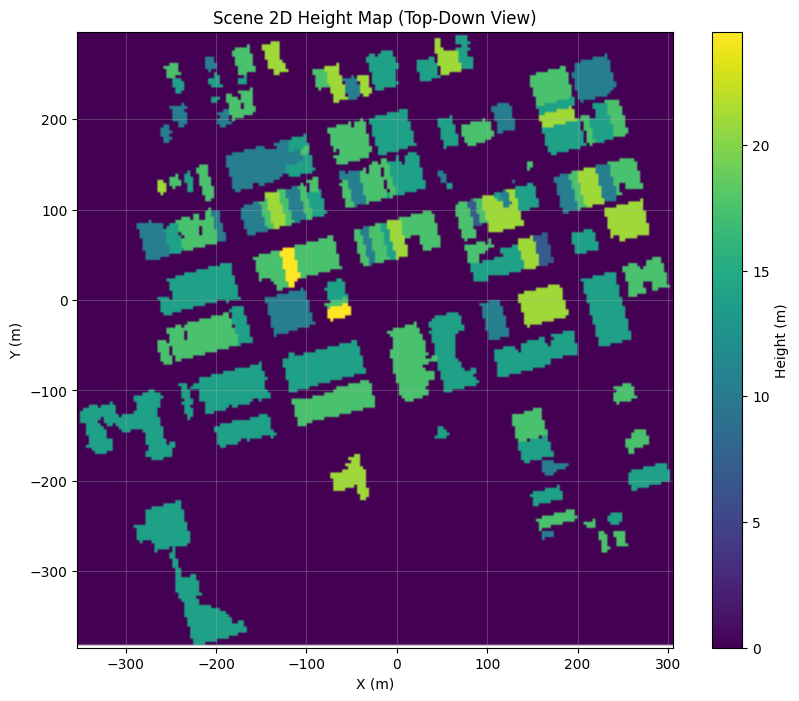

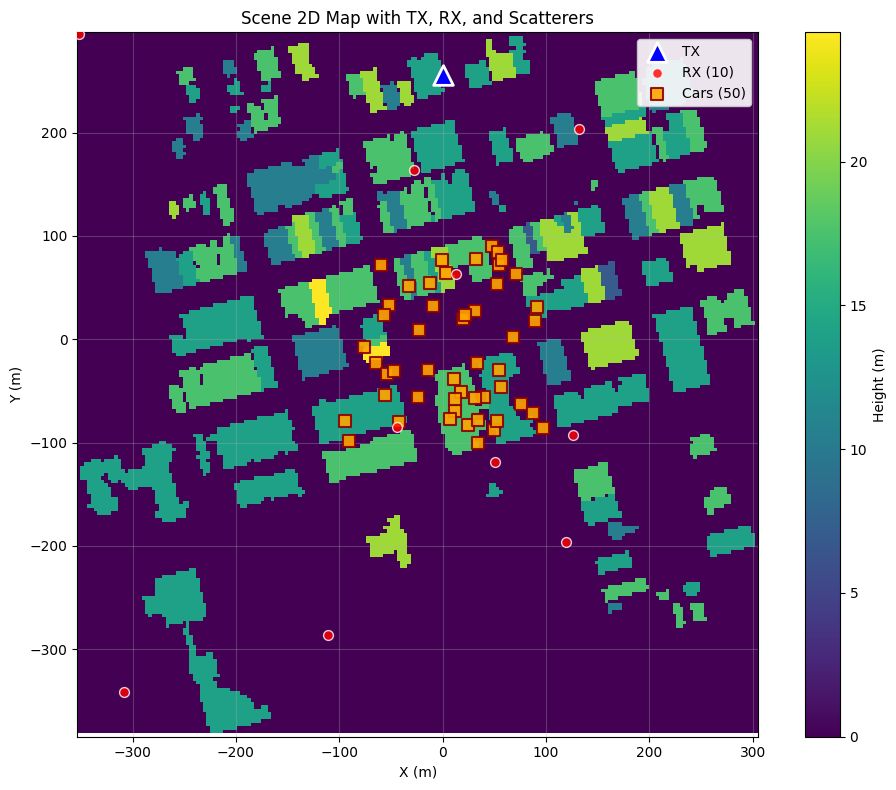

In [183]:
scene, merge_dict_paths, orig_fig, scatterer_fig, tx_position = generate_rf_augmented_csi(scene, 10, 2, 28.5e9, 50, 0, 1)

In [188]:
scene.preview(paths=merge_dict_paths['Scatterer'])

Renderer(camera=PerspectiveCamera(aspect=1.31, children=(DirectionalLight(intensity=0.25, position=(0.0, 0.0, …

In [ ]:
# def extract_cfr(paths_dict):


# def extract_cir(paths_dict):